In [1]:
import os 

#Insert API key
# os.environ['OPENAI_API_KEY'] = 'sk-GSJA3k3Re1j05j0K7es3oumDBFJl5C8kn8ronDnqPmOenE5G'
os.environ['OPENAI_API_KEY'] = 'sk-5T6oMdbJnNP23WEC5psT4I8sZyEd90Nve1YquVKdj9coHpIy'
os.environ['OPENAI_API_BASE'] = 'https://api.chatanywhere.org/v1'
# os.environ['http_proxy'] = 'http://127.0.0.1:7890'
# os.environ['https_proxy'] = 'https://127.0.0.1:7890'

In [2]:
import sys
sys.path.append("../")

#Import your prompt - we have a system message, starting prompt and iteration prompt
# ADSC is hard search with all operators (A), 
# and all tools (D (data), C (context), S (scratchpad))

from prompt_airfog import SYS_MSG, IGNITE, ITER


In [6]:
#Import experiment class
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning) 

#experiment file all different experiment settings in Python class
from experiment import airFog, airFogWithNMSE

In [6]:
#Import data
import pandas as pd
import json

df = pd.read_csv('../AirFogSim/output/global_data.csv')
data = df.to_dict(orient='list')

all_keys = list(data.keys())
all_values = list(data.values())

with open('../AirFogSim/output/context_summary.json', 'r') as f:
    context_summary = json.load(f)

y1 = all_values[7][1:]  # compute_load_avg
x11 = all_values[1][:len(y1)]   # current_task_success_ratio
x12 = all_values[8][:len(y1)]   # current_vehicle_density
x13 = all_values[9][:len(y1)]   # current_uav_density
x14 = all_values[10][:len(y1)]  # junction_0_vehicle_count
x15 = all_values[11][:len(y1)]  # junction_1_vehicle_count
x16 = all_values[12][:len(y1)]  # junction_2_vehicle_count

y2 = all_values[4][1:]  # avg_V2U_rate
x21 = all_values[8][:len(y2)]   # current_vehicle_density
x22 = all_values[9][:len(y2)]   # current_uav_density
x23 = all_values[7][:len(y2)]  # current_compute_load_avg

y3 = all_values[1][1:]  # task_success_ratio
x31 = all_values[4][:len(y3)]   # current_avg_V2U_rate
x32 = all_values[5][:len(y3)]   # current_avg_V2I_rate
x33 = all_values[7][:len(y3)]   # current_compute_load_avg

y4 = all_values[9][1:]  # uav_density
x41 = all_values[6][:len(y4)]   # current_avg_U2I_rate
x42 = all_values[7][:len(y4)]  # current_compute_load_avg
x43 = [context_summary["nonfly_zones"]["area_ratio"]] * len(y4)    # nonfly_zones.area_ratio

dep_vars = list(map(str, [y1, y2, y3, y4]))
indep_vars = list(map(list, (map(str, [x11, x12, x13, x14, x15, x16]),
                                map(str, [x21, x22, x23]),
                                map(str, [x31, x32, x33]),
                                map(str, [x41, x42, x43]))))

In [15]:
# Without context augmentation
context = """
The data is collected from a low-altitude vehicular network where vehicles and uavs collaborate to complete computational tasks under limited bandwidth and computational resources  
For each time slot, key indicators, such as task success ratio, average V2U rate, and UAV density, are recorded. 
The 4 patterns you need to analyze are all about the relationship between one key indicator of the next slot and a few key indicators of the current slot.

Pattern 1: Predict the average compute load of the next time slot based on the current task success ratio, vehicle density, UAV density and junction vehical counts. 
- Independent variable (x1): Current task success ratio.
- Independent variable (x2): Current vehicle density.
- Independent variable (x3): Current UAV density.
- Independent variable (x4): Current Junction 0 vehicle count.
- Independent variable (x5): Current Junction 1 vehicle count.
- Independent variable (x6): Current Junction 2 vehicle count.
- Dependent variable (y): Average compute load of the next time slot.

Pattern 2: Predict the average V2U rate of the next time slot based on the current vehicle density, UAV density and compute load.
- Independent variable (x1): Current vehicle density.
- Independent variable (x2): Current UAV density.
- Independent variable (x3): Current average compute load.
- Dependent variable (y): Average V2U rate of the next time slot.

Pattern 3: Predict the task success ratio of the next time slot based on the current average V2U rate, average V2I rate and compute load.
- Independent variable (x1): Current average V2U rate.
- Independent variable (x2): Current average V2I rate.
- Independent variable (x3): Current average compute load.
- Dependent variable (y): Task success ratio of the next time slot.

Pattern 4: Predict the UAV density of the next time slot based on the current average U2I rate, compute load and nonfly zone area ratio.
- Independent variable (x1): Current average U2I rate.
- Independent variable (x2): Current average compute load.
- Independent variable (x3): Nonfly zone area ratio.
- Dependent variable (y): UAV density of the next time slot.
"""

In [9]:
# With context augmentation
context = """
The data is collected from a low-altitude vehicular network where vehicles and UAVs collaborate to complete computational tasks under limited bandwidth and computational resources.

Key indicators—such as task success ratio, V2U rate, and UAV density—are recorded at each time slot. Predictive patterns describe the relationship between next-slot outcomes and current-slot indicators.

Supplementary System Context:
- Simulated system includes 50 vehicles, 30 UAVs, 8 RSUs, and 1 cloud center
- Total 370 CPU units: vehicle (2), UAV (3), RSU (10), cloud (100)
- Tasks follow Poisson process (λ=0.5), with size 0.2–0.7, deadlines 1–2s
- UAVs fly at 100m, communicate within 150m
- Map has 126 junctions, 244 edges; 5 key junctions with 8 connected roads & traffic lights
- 2 no-fly zones (total 80,000 m², ~1.1%) impact UAV routes
- UAVs and vehicles cluster near [1000, 1500, 2000]m, often around RSUs
- Vehicle density increases; UAV density remains stable → affects routing & load
- Intersections with traffic control shape congestion and movement
- Simulation proceeds in 10-second slots; indicators logged per interval
- UAV mobility limited by no-fly zones and obstacles; vehicles aggregate at junctions, RSUs, task sources

Pattern 1: Predict the average compute load of the next time slot based on the current task success ratio, vehicle density, UAV density and junction vehicle counts.
- Independent variable (x1): Current task success ratio.
- Independent variable (x2): Current vehicle density.
- Independent variable (x3): Current UAV density.
- Independent variable (x4): Current Junction 0 vehicle count.
- Independent variable (x5): Current Junction 1 vehicle count.
- Independent variable (x6): Current Junction 2 vehicle count.
- Dependent variable (y): Average compute load of the next time slot
Note: Compute load is influenced by task arrival rate (Poisson, λ=0.5), CPU capacity per node (vehicle: 2, UAV: 3, RSU: 10), and traffic congestion around key junctions.

Pattern 2: Predict the average V2U rate of the next time slot based on the current vehicle density, UAV density and compute load.
- Independent variable (x1): Current vehicle density.
- Independent variable (x2): Current UAV density.
- Independent variable (x3): Current average compute load.
- Dependent variable (y): Average V2U rate of the next time slot
Note: V2U communication is influenced by UAV density, vehicle distribution, and spatial constraints. UAVs operate at 100 meters altitude and have a communication range of 150 meters. There are 8 RSUs distributed across the area, which affects link availability.

Pattern 3: Predict the task success ratio of the next time slot based on the current average V2U rate, average V2I rate and compute load.
- Independent variable (x1): Current average V2U rate.
- Independent variable (x2): Current average V2I rate.
- Independent variable (x3): Current average compute load.
- Dependent variable (y): Task success ratio of the next time slot
Note: Task success ratio is constrained by deadline (TTL 1–2s), link latency, and current compute load saturation across UAVs and RSUs.

Pattern 4: Predict the UAV density of the next time slot based on the current average U2I rate, compute load and nonfly zone area ratio.
- Independent variable (x1): Current average U2I rate.
- Independent variable (x2): Current average compute load.
- Independent variable (x3): Nonfly zone area ratio.
- Dependent variable (y): UAV density of the next time slot
Note: UAV density is constrained by the presence of two non-fly zones (totaling 80,000 m² or ~1.1% of the area), which limit the available flight space and cause spatial redistribution of UAVs.
"""

Running experiment 1...
Iteration:Seed
SciPy feedback used for this iteration:
None
LLM thoughts:
Pattern 1: 
- The dependent variable, y (average compute load of the next time slot), is influenced by the current task success ratio (x1), vehicle density (x2), UAV density (x3), and vehicle counts at junctions (x4, x5, x6). 
- The task success ratio (x1) and vehicle density (x2) seem to have a non-linear influence on y. 
- A combination of polynomial terms and interactions between x1, x2, and x3 could describe the pattern. 
- Expressions could involve squares or products of these variables to capture interactions.

Pattern 2: 
- The dependent variable, y (average V2U rate of the next time slot), is influenced by vehicle density (x1), UAV density (x2), and compute load (x3). 
- Since V2U communication depends on spatial distribution and densities, non-linear combinations involving x1, x2, and x3 should be considered. 
- Given the strong influence of densities, expressions with products of

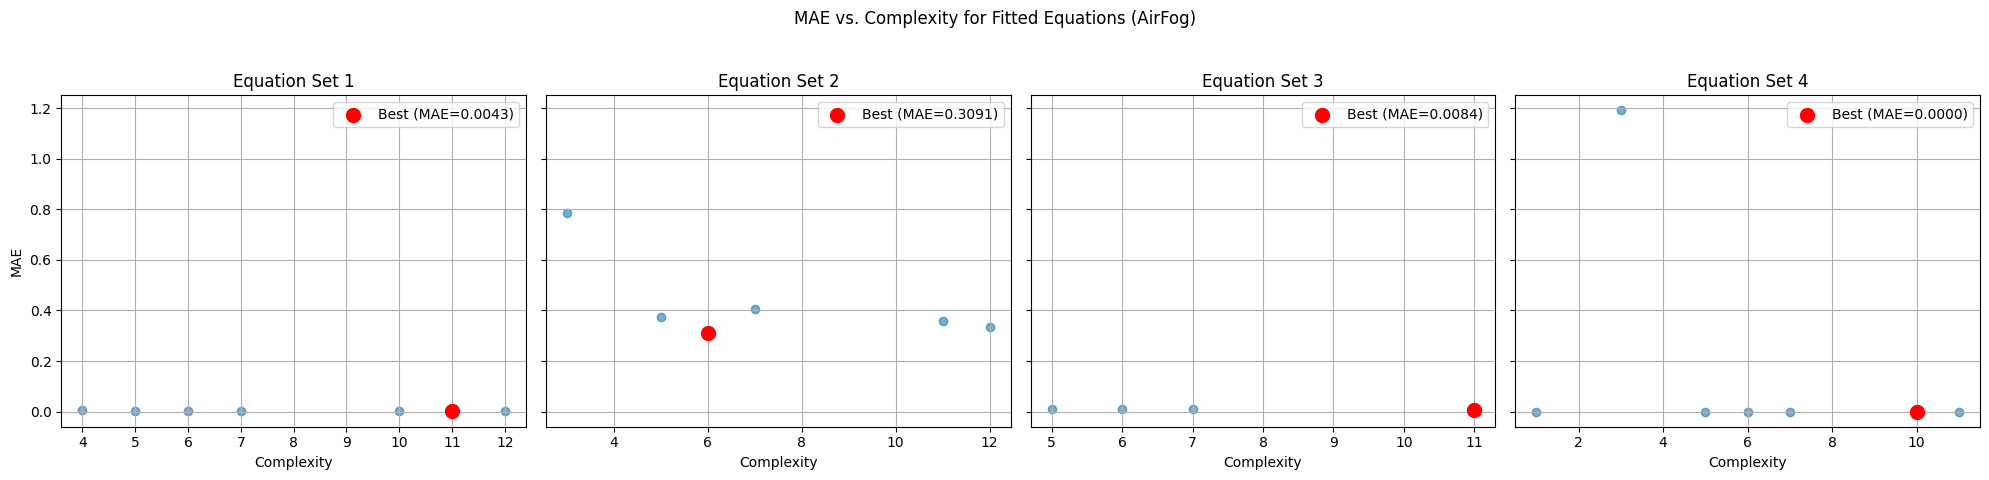

Experiment 1 finished.
Running experiment 2...
Iteration:Seed
SciPy feedback used for this iteration:
None
LLM thoughts:
x1, x2, x3, x4, x5, x6 = symbols('x1 x2 x3 x4 x5 x6')
c0, c1, c2, c3, c4, c5, c6 = symbols('c0 c1 c2 c3 c4 c5 c6')

# Analysis for Pattern 1
# The dependent variable y represents the average compute load of the next time slot.
# Various factors influence this, including task success ratio, vehicle density, UAV density, and vehicle counts at junctions.
# Based on the description, both linear and non-linear relationships might exist. A common approach could be linear combination or simple non-linear transformations.

# Expressions for Pattern 1:
expr1_pattern1 = c0 + c1*x1 + c2*x2 + c3*x4
expr2_pattern1 = c0 + c1*x1*x2 + c2*x4*x5
expr3_pattern1 = c0 + c1*x1*x2*x3

# Analysis for Pattern 2
# The dependent variable y represents the average V2U rate of the next time slot.
# Influenced by vehicle density, UAV density, and compute load, which are crucial indicators of commu

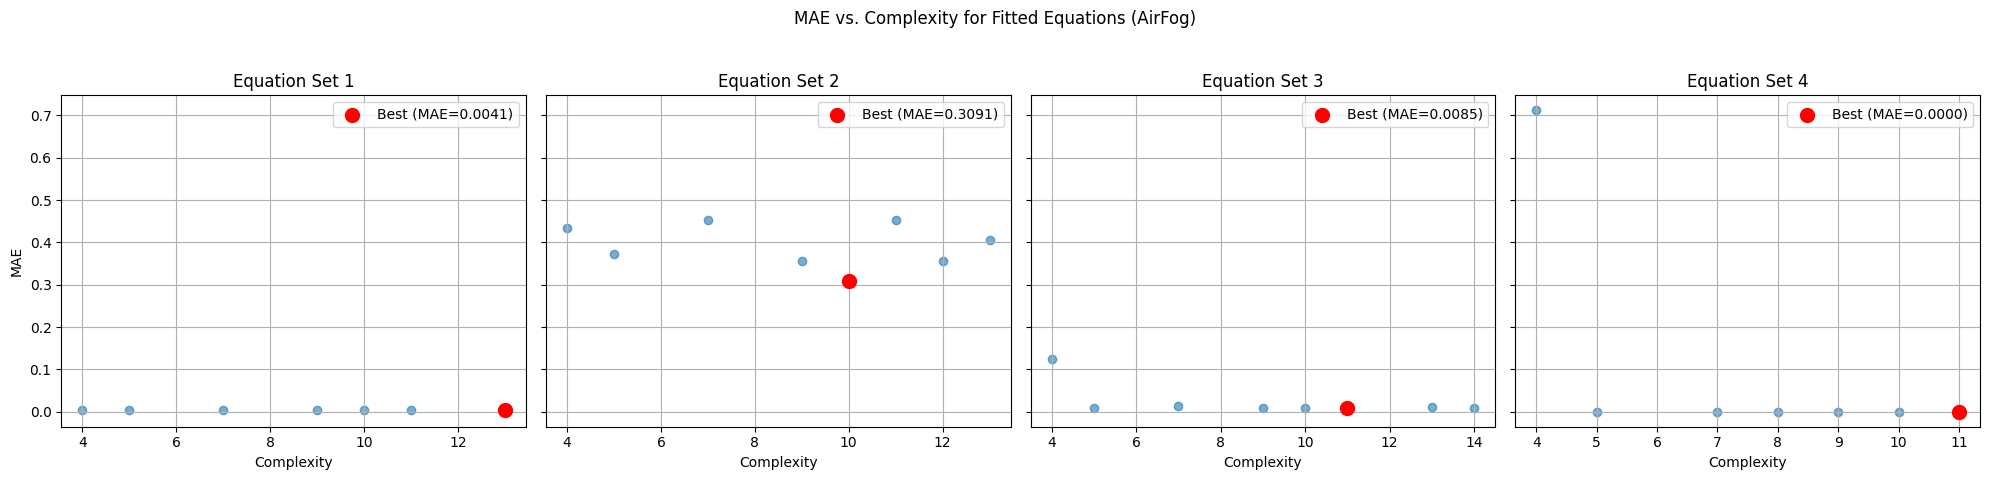

Experiment 2 finished.
Running experiment 3...
Iteration:Seed
SciPy feedback used for this iteration:
None
LLM thoughts:
For Pattern 1, the dataset shows a relationship where the dependent variable, average compute load, is influenced by variables such as task success ratio and vehicle density. These can be captured using linear and polynomial expressions with x1, x2, and x4 showing notable influence. The data suggest that a combination of linear and polynomial terms would be suitable. 

For Pattern 2, the average V2U rate appears to show a strong dependency on the vehicle density (x1) and UAV density (x2), as these factors directly influence communication capacity and collisions. Polynomial expressions of x1 and x2, alongside the compute load (x3), may effectively capture this relationship.

In Pattern 3, the task success ratio is closely linked to the average V2U rate (x1) and average V2I rate (x2), as they directly impact communication efficiency. Linear terms along with polynomial 

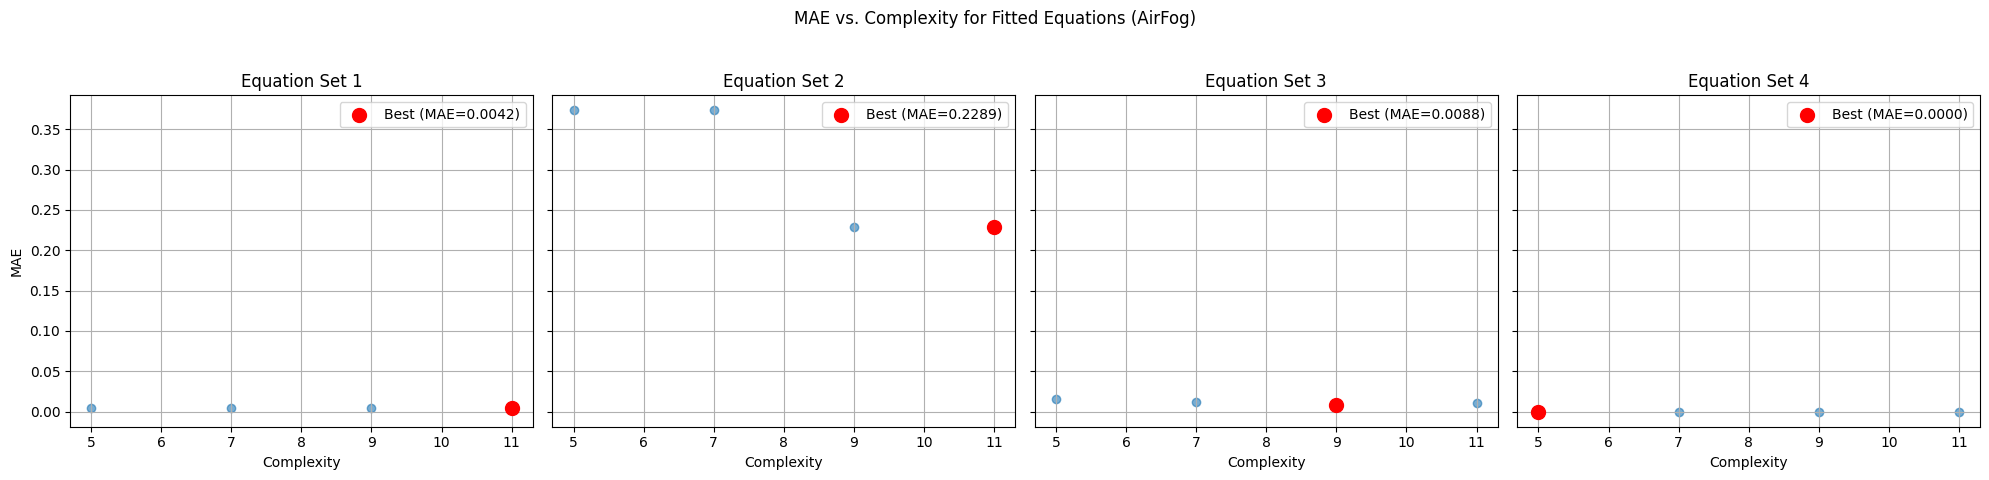

Experiment 3 finished.


In [10]:
# Using MAE as the error function

import json
#No. of expressions generated in each LLM call
N = 3
temp = 0.7
model = "gpt-4o"

#Increase iterations here
total_iterations = 5 

sys_msg= SYS_MSG
ignite_msg = IGNITE
iter_msg = ITER

results_fromAllruns = []
iteration_infos_fromAllruns = []


# Run the experiment n times
for i in range(3):
    print(f"Running experiment {i+1}...")

    # Create a new instance of the experiment class with your settings
    #options = allTools, noContext, noData, noScratchpad
    experiment = airFog(dep_vars, indep_vars, N, temp, context, sys_msg, ignite_msg, iter_msg, model)
    # Run the experiment and store the results
    results, all_expressions, iteration_info, usage_list, total_chain_run_time, all_expressionsLLM = experiment.run(total_iterations)
    
    results_fromAllruns.append({
        'CombResults': results, 
        'all_expressions': all_expressions, 
        'usage_list': usage_list, 
        'total_chain_run_time': total_chain_run_time,
        'LLM raw expressions': all_expressionsLLM
    })
    
    # Store the iteration info
    iteration_infos_fromAllruns.append(iteration_info)

    # print(f"Experiment {i+1} finished. Cost: {experiment.cost()}")
    print(f"Experiment {i+1} finished.")

    directory_path = "tests/AirFog"
    if not os.path.exists(directory_path):
        os.makedirs(directory_path)  # This will create all intermediate-level directories needed to contain the leaf directory

    with open(f"{directory_path}/PromptsUsed.txt", 'w') as f:
        f.write(f"##Sytstem Message## {SYS_MSG}\n")
        f.write(f"##Starting Prompt## {IGNITE}\n")
        f.write(f"##Iteration Prompt## {ITER}\n")

    with open(f"{directory_path}/run{i+1}.txt", 'w') as f:
        f.write("Final Results:\n")
        for res in results:
            json.dump(res, f, indent=2)
            f.write("\n")
        # f.write(f"Cost for this run: ${experiment.cost()}\n")
        f.write(f"Total chain run time: {total_chain_run_time} seconds.\n")
        f.write("\n\nIteration Information:\n")
        for info in iteration_info:
            json.dump(info, f, indent=2)
            f.write("\n")

In [ ]:
# Using fitness function with NMSE as the error function

import json
#No. of expressions generated in each LLM call
N = 3
temp = 0.7
model = "gpt-4o"

#Increase iterations here
total_iterations = 5 

sys_msg= SYS_MSG
ignite_msg = IGNITE
iter_msg = ITER

results_fromAllruns = []
iteration_infos_fromAllruns = []


# Run the experiment n times
for i in range(3):
    print(f"Running experiment {i+1}...")

    # Create a new instance of the experiment class with your settings
    #options = allTools, noContext, noData, noScratchpad
    experiment = airFogWithNMSE(dep_vars, indep_vars, N, temp, context, sys_msg, ignite_msg, iter_msg, model)
    # Run the experiment and store the results
    results, all_expressions, iteration_info, usage_list, total_chain_run_time, all_expressionsLLM = experiment.run(total_iterations)
    
    results_fromAllruns.append({
        'CombResults': results, 
        'all_expressions': all_expressions, 
        'usage_list': usage_list, 
        'total_chain_run_time': total_chain_run_time,
        'LLM raw expressions': all_expressionsLLM
    })
    
    # Store the iteration info
    iteration_infos_fromAllruns.append(iteration_info)

    # print(f"Experiment {i+1} finished. Cost: {experiment.cost()}")
    print(f"Experiment {i+1} finished.")

    directory_path = "tests/AirFog"
    if not os.path.exists(directory_path):
        os.makedirs(directory_path)  # This will create all intermediate-level directories needed to contain the leaf directory

    with open(f"{directory_path}/PromptsUsed.txt", 'w') as f:
        f.write(f"##Sytstem Message## {SYS_MSG}\n")
        f.write(f"##Starting Prompt## {IGNITE}\n")
        f.write(f"##Iteration Prompt## {ITER}\n")

    with open(f"{directory_path}/run{i+1}.txt", 'w') as f:
        f.write("Final Results:\n")
        for res in results:
            json.dump(res, f, indent=2)
            f.write("\n")
        # f.write(f"Cost for this run: ${experiment.cost()}\n")
        f.write(f"Total chain run time: {total_chain_run_time} seconds.\n")
        f.write("\n\nIteration Information:\n")
        for info in iteration_info:
            json.dump(info, f, indent=2)
            f.write("\n")